In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

In [2]:
# Download Data
adani = yf.download('ADANIGREEN.NS', start='2024-05-22', end='2025-05-22')
bel = yf.download('BEL.NS', start='2024-05-22', end='2025-05-22')

adani.head()

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,ADANIGREEN.NS,ADANIGREEN.NS,ADANIGREEN.NS,ADANIGREEN.NS,ADANIGREEN.NS
Date,,,,,
2024-05-22,1866.449951,1898.000000,1860.000000,1879.000000,578311
2024-05-23,1888.800049,1909.000000,1845.550049,1870.000000,3893291
2024-05-24,1926.650024,1949.000000,1889.050049,1898.800049,2928305
2024-05-27,1929.500000,1958.800049,1891.000000,1943.699951,4354846
2024-05-28,1893.650024,1935.000000,1865.150024,1935.000000,1846867


In [3]:
# Flatten MultiIndex columns
adani.columns.name = None
bel.columns.name = None
adani.columns = adani.columns.get_level_values(0)
bel.columns = bel.columns.get_level_values(0)

adani.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2024-05-22,1866.449951,1898.000000,1860.000000,1879.000000,578311
2024-05-23,1888.800049,1909.000000,1845.550049,1870.000000,3893291
2024-05-24,1926.650024,1949.000000,1889.050049,1898.800049,2928305
2024-05-27,1929.500000,1958.800049,1891.000000,1943.699951,4354846
2024-05-28,1893.650024,1935.000000,1865.150024,1935.000000,1846867


In [4]:
# --- Strategy 1: EMA Crossover (vectorized) ---
def ema_crossover_strategy(df: pd.DataFrame, period: int = 14) -> pd.DataFrame:
    df = df.copy()
    ema = df['Close'].ewm(span=period, adjust=False).mean()
    prev = df['Close'].shift(1)
    prev_ema = ema.shift(1)
    df['signal'] = np.where((df['Close'] > ema) & (prev <= prev_ema), 1,
                      np.where((df['Close'] < ema) & (prev >= prev_ema), -1, 0))
    df[f'ema_{period}'] = ema
    return df

In [5]:
# --- Strategy 2: EMA + Range Band (vectorized) ---
def ema_with_range_band(df: pd.DataFrame, period: int = 14) -> pd.DataFrame:
    df = df.copy()
    ema = df['Close'].ewm(span=period, adjust=False).mean()
    band = df['High'] - df['Low']
    buy_band = ema + band
    sell_band = ema - band
    prev_close = df['Close'].shift(1)
    df['signal'] = np.where(
        (df['Close'] > buy_band) & (prev_close <= buy_band.shift(1)), 1,
        np.where((df['Close'] < sell_band) & (prev_close >= sell_band.shift(1)), -1, 0)
    )
    df[f'ema_{period}'] = ema
    df['buy_band'] = buy_band
    df['sell_band'] = sell_band
    return df

In [6]:

'''
def atr_breakout_strategy(df: pd.DataFrame, period: int = 14, k: float = 1.5) -> pd.DataFrame:

    df = df.copy()
    ema = df['Close'].ewm(span=period, adjust=False).mean()
    tr = pd.concat([
        df['High'] - df['Low'],
        (df['High'] - df['Close'].shift(1)).abs(),
        (df['Low'] - df['Close'].shift(1)).abs()
    ], axis=1).max(axis=1)
    atr = tr.ewm(span=period, adjust=False).mean()
    buy = ema + k * atr
    sell = ema - k * atr
    prev = df['Close'].shift(1)
    df['signal'] = np.where((df['Close'] > buy) & (prev <= buy.shift(1)), 1,
                      np.where((df['Close'] < sell) & (prev >= sell.shift(1)), -1, 0))
    df[f'ema_{period}'] = ema
    df['atr'] = atr
    df['buy_band'] = buy
    df['sell_band'] = sell
    return df
'''

"\ndef atr_breakout_strategy(df: pd.DataFrame, period: int = 14, k: float = 1.5) -> pd.DataFrame:\n\n    df = df.copy()\n    ema = df['Close'].ewm(span=period, adjust=False).mean()\n    tr = pd.concat([\n        df['High'] - df['Low'],\n        (df['High'] - df['Close'].shift(1)).abs(),\n        (df['Low'] - df['Close'].shift(1)).abs()\n    ], axis=1).max(axis=1)\n    atr = tr.ewm(span=period, adjust=False).mean()\n    buy = ema + k * atr\n    sell = ema - k * atr\n    prev = df['Close'].shift(1)\n    df['signal'] = np.where((df['Close'] > buy) & (prev <= buy.shift(1)), 1,\n                      np.where((df['Close'] < sell) & (prev >= sell.shift(1)), -1, 0))\n    df[f'ema_{period}'] = ema\n    df['atr'] = atr\n    df['buy_band'] = buy\n    df['sell_band'] = sell\n    return df\n"

In [7]:
# --- Strategy 3: ATR Breakout (vectorized) ---
def atr_breakout_strategy(df: pd.DataFrame, period: int = 14, k: float = 1.5) -> pd.DataFrame:
    df = df.copy()
    ema = df['Close'].ewm(span=period, adjust=False).mean()
    # Compute True Range using a DataFrame to align indices
    tr_df = pd.DataFrame({
        'hl': df['High'] - df['Low'],
        'hc': (df['High'] - df['Close'].shift(1)).abs(),
        'lc': (df['Low'] - df['Close'].shift(1)).abs()
    }, index=df.index)
    tr = tr_df.max(axis=1)
    atr = tr.ewm(span=period, adjust=False).mean()
    buy = ema + k * atr
    sell = ema - k * atr
    prev = df['Close'].shift(1)
    df['signal'] = np.where((df['Close'] > buy) & (prev <= buy.shift(1)), 1,
                      np.where((df['Close'] < sell) & (prev >= sell.shift(1)), -1, 0))
    df[f'ema_{period}'] = ema
    df['atr'] = atr
    df['buy_band'] = buy
    df['sell_band'] = sell
    return df

=== ADANIGREEN EDA ===
EMA Crossover: Buys=17, Sells=16


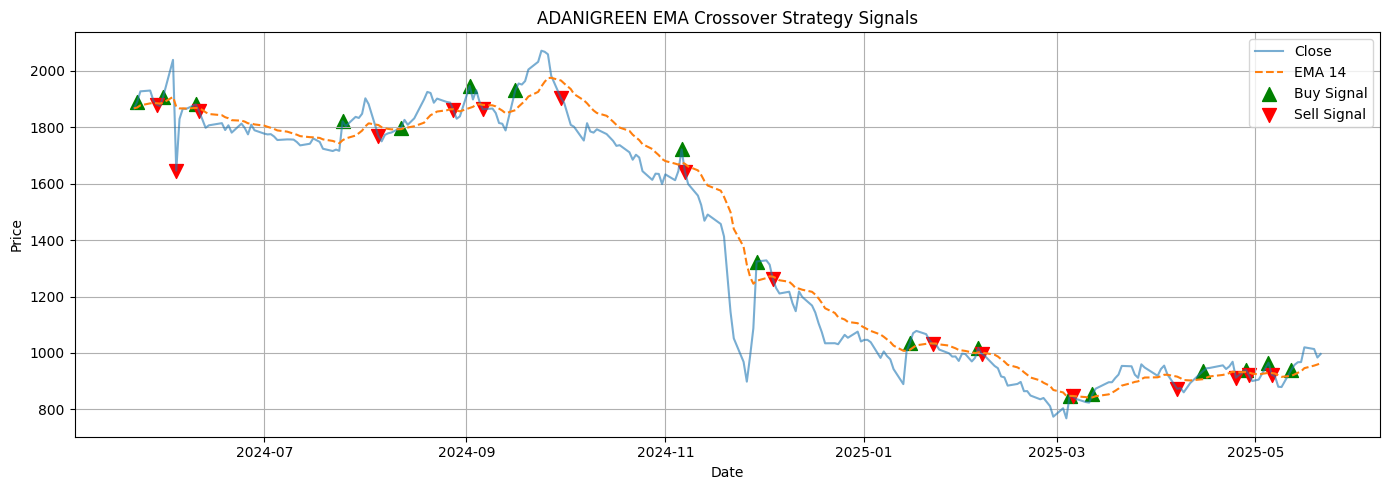

EMA + Range Band: Buys=12, Sells=22


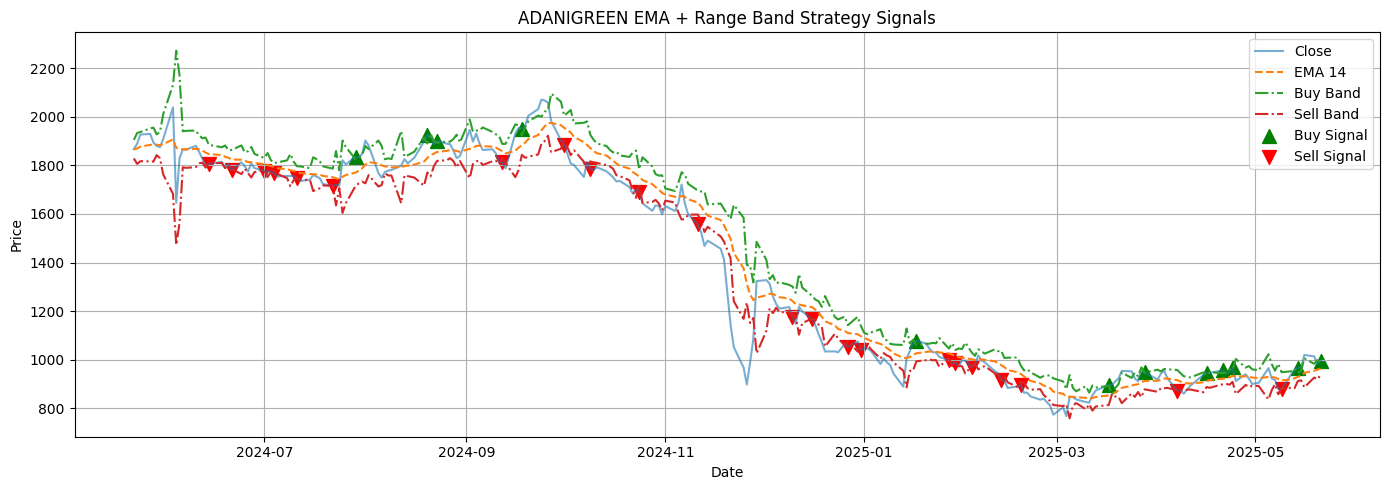

=== BEL EDA ===
EMA Crossover: Buys=14, Sells=13


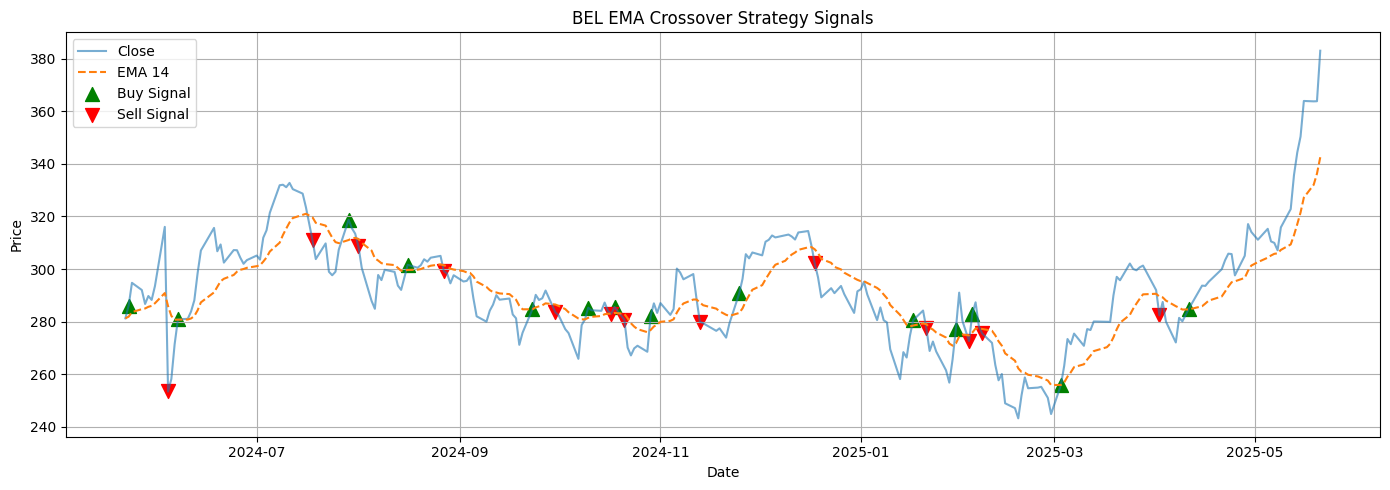

EMA + Range Band: Buys=19, Sells=17


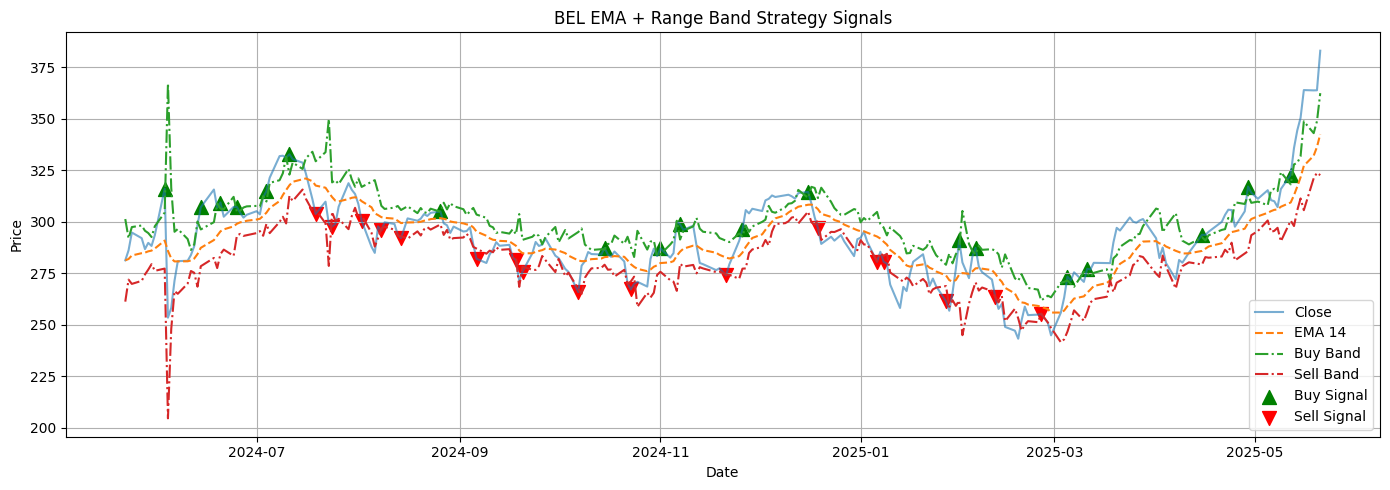

In [8]:
# --- Signal Plotting ---
def plot_strategy_signals(df: pd.DataFrame, name: str, period: int = 14, k: float = 1.5):
    df = df.copy()
    plt.figure(figsize=(14,5))
    # Base price
    plt.plot(df['Close'], label='Close', alpha=0.6)
    # EMA line for all strategies
    ema_col = f'ema_{period}'
    if ema_col in df:
        plt.plot(df[ema_col], '--', label=f'EMA {period}')
    # Range bands (EMA+Range)
    if 'buy_band' in df and 'sell_band' in df:
        plt.plot(df['buy_band'], '-.', label='Buy Band')
        plt.plot(df['sell_band'], '-.', label='Sell Band')
    # ATR bands (ATR Breakout)
    elif 'atr' in df and 'buy_band' in df and 'sell_band' in df:
        plt.plot(df['buy_band'], '-.', label=f'EMA+{k}*ATR')
        plt.plot(df['sell_band'], '-.', label=f'EMA-{k}*ATR')

    # Signal markers
    buys = df[df['signal'] == 1]
    sells = df[df['signal'] == -1]
    plt.scatter(buys.index, buys['Close'], marker='^', color='green', label='Buy Signal', s=100)
    plt.scatter(sells.index, sells['Close'], marker='v', color='red', label='Sell Signal', s=100)

    plt.title(f'{name} Strategy Signals')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# EDA
for symbol, data in [('ADANIGREEN', adani), ('BEL', bel)]:
    print(f"=== {symbol} EDA ===")
    for name, func in [
        ('EMA Crossover', ema_crossover_strategy),
        ('EMA + Range Band', ema_with_range_band),
        # ('ATR Breakout', atr_breakout_strategy)
    ]:
        df_strat = func(data.copy())
        sig = df_strat['signal']
        print(f"{name}: Buys={(sig==1).sum()}, Sells={(sig==-1).sum()}")
        plot_strategy_signals(df_strat, f"{symbol} {name}")

In [9]:
# === Backtesting Engine ===
def backtest_strategy(df: pd.DataFrame, initial_capital: float = 1_000_000):
    required_cols = ['Close', 'signal']
    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Required column '{col}' not found in DataFrame. Available columns: {df.columns.tolist()}")

    df = df.copy().dropna(subset=['signal','Close'])
    print(df.columns)
    cash = initial_capital
    position = 0
    entry_price = 0.0
    entry_idx = None
    qty = 0
    trade_log = []
    daily_log = []

    for i, date in enumerate(df.index):
        price = df.at[date, 'Close']
        signal = df.at[date, 'signal']
        # update daily portfolio value
        if position == 1:
            pv = cash + qty * price
        elif position == -1:
            pv = cash + (entry_price - price) * qty
        else:
            pv = cash
        daily_log.append({'Date': date, 'Portfolio Value': pv, 'Position': position, 'Quantity': qty, 'Cash': cash})
        # exit
        if position != 0 and signal == -position:
            exit_price = price
            ret_pct = (exit_price - entry_price)/entry_price * position * 100
            period = df.iloc[entry_idx:i]
            if position == 1:
                mae = (entry_price - period['Low'].min())/entry_price*100
                peak = period['High'].cummax()
                mdd = ((peak - period['Close'])/peak).max()*100
            else:
                mae = (period['High'].max() - entry_price)/entry_price*100
                trough = period['Low'].cummin()
                mdd = ((period['Close'] - trough)/trough).max()*100
            trade_log.append({'Entry Index': entry_idx,'Exit Index': i,'Entry Date': df.index[entry_idx],'Exit Date': date,
                               'Duration': (date - df.index[entry_idx]).days,'Return%': ret_pct,'Type': 'Long' if position==1 else 'Short',
                               'Max Drawdown%': mdd,'Max Dip%': mae,'Quantity': qty})
            # settle
            if position == 1:
                cash += qty * exit_price
            else:
                cash += qty * entry_price - qty * exit_price
            position, qty = 0, 0
        # entry
        if position == 0 and signal != 0:
            position = signal
            entry_price = price
            entry_idx = i
            qty = int(cash // price)
            if position == 1:
                cash -= qty * price
            else:
                cash += qty * price
    # close open
    if position != 0:
        date = df.index[-1]; price = df['Close'].iloc[-1]
        ret_pct = (price - entry_price)/entry_price * position * 100
        period = df.iloc[entry_idx:]
        if position == 1:
            mae = (entry_price - period['Low'].min())/entry_price*100
            peak = period['High'].cummax()
            mdd = ((peak - period['Close'])/peak).max()*100
            cash += qty * price
        else:
            mae = (period['High'].max() - entry_price)/entry_price*100
            trough = period['Low'].cummin()
            mdd = ((period['Close'] - trough)/trough).max()*100
            cash += qty * entry_price - qty * price
        trade_log.append({'Entry Index': entry_idx,'Exit Index': len(df)-1,'Entry Date': df.index[entry_idx],'Exit Date': date,
                           'Duration': (date - df.index[entry_idx]).days,'Return%': ret_pct,'Type': 'Long' if position==1 else 'Short',
                           'Max Drawdown%': mdd,'Max Dip%': mae,'Quantity': qty})
        daily_log.append({'Date': date, 'Portfolio Value': cash, 'Position': 0, 'Quantity': 0, 'Cash': cash})

    trades_df = pd.DataFrame(trade_log)
    daily_df = pd.DataFrame(daily_log).set_index('Date')
    daily_df['Profit%'] = (daily_df['Portfolio Value']/initial_capital - 1)*100
    return trades_df, daily_df

In [10]:
# === Metrics Calculation ===
def compute_metrics(trades_df: pd.DataFrame, daily_df: pd.DataFrame, price_df: pd.DataFrame, initial_capital: float = 1_000_000):
    bench = (price_df['Close'].iloc[-1]/price_df['Close'].iloc[0]-1)*100
    net = daily_df['Portfolio Value'].iloc[-1]/initial_capital*100 - 100
    wins = trades_df[trades_df['Return%']>0]
    gross = wins['Return%'].sum() if not wins.empty else 0
    total = len(trades_df); w = len(wins); l = total - w
    max_dur = trades_df['Duration'].max() if total else 0
    avg_dur = trades_df['Duration'].mean() if total else 0
    peak = daily_df['Portfolio Value'].cummax()
    dd = (daily_df['Portfolio Value']-peak)/peak*100
    max_dd = dd.min(); avg_dd = dd[dd<0].mean()
    max_dip = trades_df['Max Dip%'].max() if total else 0
    avg_dip = trades_df['Max Dip%'].mean() if total else 0
    dr = daily_df['Profit%'].pct_change().fillna(0)
    sharpe = dr.mean()/dr.std()*np.sqrt(252) if dr.std() else 0

    raw = pd.Series({
        'Benchmark Return%': bench,
        'Net Profit%': net,
        'Gross Profit%': gross,
        'Total Trades': total,
        'Winning Trades': w,
        'Losing Trades': l,
        'Max Holding Time': max_dur,
        'Avg Holding Time': avg_dur,
        'Max Drawdown%': max_dd,
        'Avg Drawdown%': avg_dd,
        'Max Dip%': max_dip,
        'Avg Dip%': avg_dip,
        'Sharpe Ratio': sharpe
    })

    return raw.map(lambda x: f"{x:.2f}" if isinstance(x, float) else x)

=== Backtest ADANIGREEN - EMA Crossover ===
ADANIGREEN DataFrame columns: ['Close', 'High', 'Low', 'Open', 'Volume', 'signal', 'ema_14']
Price             Close         High          Low         Open   Volume  \
Date                                                                      
2025-05-15   967.900024   972.799988   953.400024   972.099976  4951675   
2025-05-16  1020.099976  1025.000000   965.200012   971.450012  7644511   
2025-05-19  1014.000000  1038.349976  1010.049988  1031.949951  3176879   
2025-05-20   983.950012  1020.950012   981.799988  1016.000000  2713486   
2025-05-21   996.500000  1003.000000   977.200012   985.000000  2228757   

Price       signal      ema_14  
Date                            
2025-05-15       0  934.933398  
2025-05-16       0  946.288942  
2025-05-19       0  955.317083  
2025-05-20       0  959.134807  
2025-05-21       0  964.116833  
Index(['Close', 'High', 'Low', 'Open', 'Volume', 'signal', 'ema_14'], dtype='object', name='Price')
Benchm

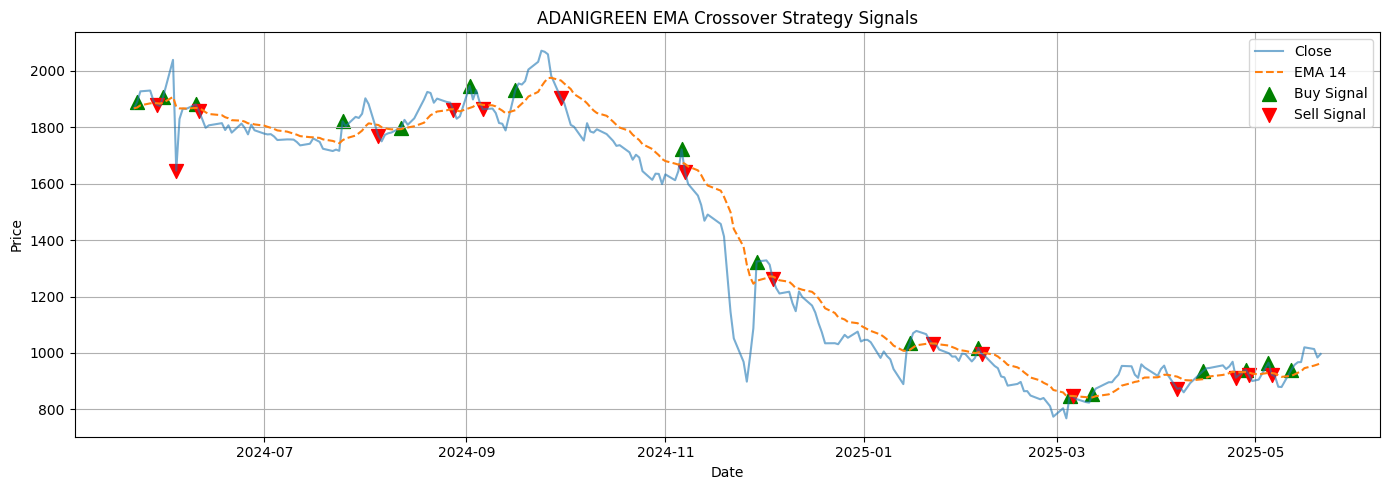


----------------------------------------------------------------------------------------------------

=== Backtest BEL - EMA Crossover ===
BEL DataFrame columns: ['Close', 'High', 'Low', 'Open', 'Volume', 'signal', 'ema_14']
Price            Close        High         Low        Open    Volume  signal  \
Date                                                                           
2025-05-15  350.399994  351.000000  340.799988  346.500000  35959338       0   
2025-05-16  363.899994  371.149994  349.600006  351.600006  68855818       0   
2025-05-19  363.750000  373.500000  362.549988  372.899994  52003735       0   
2025-05-20  363.799988  371.000000  358.500000  369.399994  67088831       0   
2025-05-21  383.000000  383.899994  364.000000  366.899994  88688170       0   

Price           ema_14  
Date                    
2025-05-15  321.516292  
2025-05-16  327.167452  
2025-05-19  332.045125  
2025-05-20  336.279107  
2025-05-21  342.508559  
Index(['Close', 'High', 'Low', 'Open',

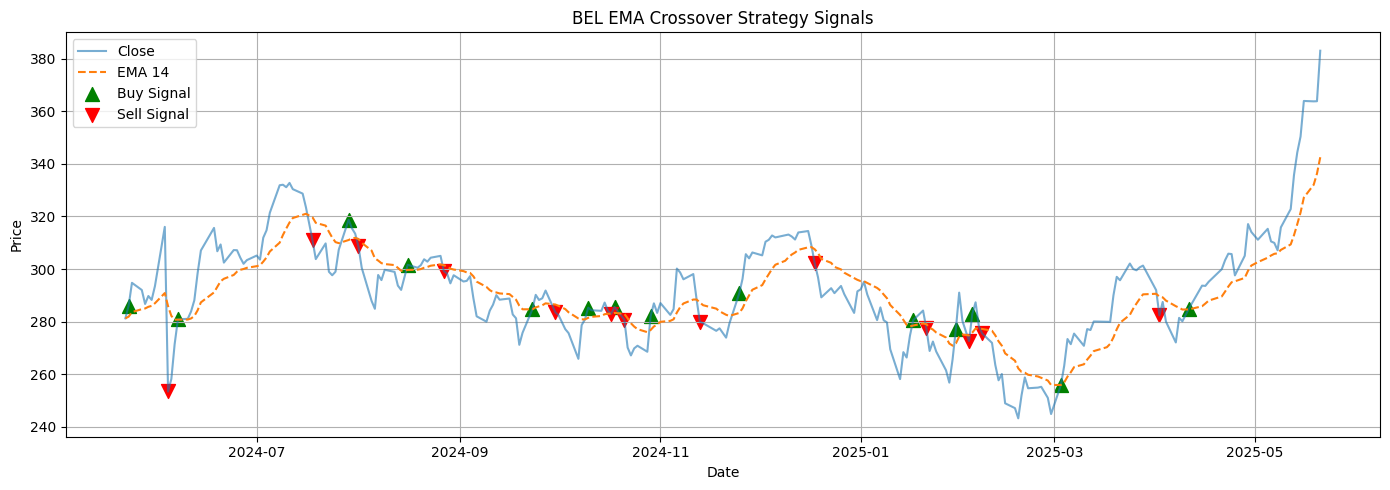


----------------------------------------------------------------------------------------------------



In [11]:
# === Demonstration of Backtest ===
for symbol, data in [('ADANIGREEN', adani), ('BEL', bel)]:
    print(f"=== Backtest {symbol} - EMA Crossover ===")
    df_strat = ema_crossover_strategy(data.copy())

    print(f"{symbol} DataFrame columns: {df_strat.columns.tolist()}")
    print(df_strat.tail())

    trades, daily = backtest_strategy(df_strat)
    print(compute_metrics(trades, daily, data))
    plot_strategy_signals(df_strat, f"{symbol} EMA Crossover")
    print("\n" + "-"*100 + "\n")

In [23]:
# Load the VIX CSV with correct column name
vix_df = pd.read_csv('/content/hist_india_vix_-22-05-2024-to-22-05-2025.csv')

# Clean column names (strip whitespace)
vix_df.columns = vix_df.columns.str.strip()

# Set 'Date' as index
# vix_df.set_index('Date', inplace=True)

# Display the cleaned dataframe
vix_df.columns.to_list()

['Date', 'Open', 'High', 'Low', 'Close', 'Prev. Close', 'Change', '% Change']

In [24]:
vix_mean = vix_df['Close'].mean()
vix_std = vix_df['Close'].std()

print(f"VIX Mean: {vix_mean:.2f}")
print(f"VIX Std Dev: {vix_std:.2f}")

VIX Mean: 15.12
VIX Std Dev: 2.51


In [25]:
# Define thresholds
threshold_1 = vix_mean + 0.5 * vix_std
threshold_2 = vix_mean + 1.5 * vix_std

print(f"Threshold 1 (100% → 75% capital): {threshold_1:.2f}")
print(f"Threshold 2 (75% → 50% capital): {threshold_2:.2f}")

Threshold 1 (100% → 75% capital): 16.37
Threshold 2 (75% → 50% capital): 18.88


In [42]:
# Vectorized capital allocation function (based on full date index)
def capital_allocation(dates: pd.DatetimeIndex, vix: pd.Series, threshold_1: float, threshold_2: float) -> pd.Series:
    vf = vix.reindex(dates, method='ffill').fillna(method='bfill')
    cf = pd.Series(1.0, index=dates)
    cf[(vf >= threshold_1) & (vf < threshold_2)] = 0.75
    cf[vf >= threshold_2] = 0.50
    return cf

# Calculate mean and std for thresholds
vix_mean = vix_df['Close'].mean()
vix_std = vix_df['Close'].std()
threshold_1 = vix_mean + 0.5 * vix_std
threshold_2 = vix_mean + 1.5 * vix_std

# Apply capital allocation over the entire date index of vix_df
vix_df['allocation'] = capital_allocation(vix_df.index, vix_df['Close'], threshold_1, threshold_2)

# Display result
vix_df[['Close', 'allocation']].tail()

<ipython-input-42-8fb86787dbe5>:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  vf = vix.reindex(dates, method='ffill').fillna(method='bfill')


,Close,allocation
243,16.89,0.75
244,16.55,0.75
245,17.36,0.75
246,17.39,0.75
247,17.55,0.75


In [43]:
# --- VaR and CVaR Calculation Functions ---

CONFIDENCE_LEVEL_VAR_CVAR = 0.95
def calculate_var(daily_returns, confidence_level=CONFIDENCE_LEVEL_VAR_CVAR):
    """Calculates Value at Risk (VaR)."""
    if not isinstance(daily_returns, pd.Series) or daily_returns.empty:
        return np.nan
    var = np.percentile(daily_returns.dropna(), 100 * (1 - confidence_level))
    return var

def calculate_cvar(daily_returns, confidence_level=CONFIDENCE_LEVEL_VAR_CVAR):
    """Calculates Conditional Value at Risk (CVaR) / Expected Shortfall."""
    if not isinstance(daily_returns, pd.Series) or daily_returns.empty:
        return np.nan
    var = calculate_var(daily_returns, confidence_level)
    if np.isnan(var):
        return np.nan
    cvar = daily_returns[daily_returns < var].mean()
    return cvar

In [44]:
def backtest_dynamic(df: pd.DataFrame,
                     signals: pd.Series,
                     initial_capital: float,
                     capital_factors: pd.Series):
    cash = initial_capital
    position = 0
    entry_price = 0.0
    entry_idx = None
    qty = 0
    trades = []
    daily = []

    for i, date in enumerate(df.index):
        price = df.at[date, 'Close']
        signal = signals.reindex(df.index).iat[i]
        # portfolio value before action
        if position == 1:
            pv = cash + qty * price
        elif position == -1:
            pv = cash + (entry_price - price) * qty
        else:
            pv = cash
        # today's allocation
        alloc = pv * capital_factors.loc[date]
        daily.append({'Date': date, 'Portfolio Value': pv})

        # exit
        if position != 0 and signal == -position:
            exit_price = price
            ret_pct = (exit_price - entry_price) / entry_price * position * 100
            trades.append({
                'Entry Date': df.index[entry_idx],
                'Exit Date': date,
                'Return%': ret_pct,
                'Type': 'Long' if position==1 else 'Short',
                'Quantity': qty
            })
            # settle
            if position == 1:
                cash += qty * exit_price
            else:
                cash += qty*entry_price - qty*exit_price
            position, qty = 0, 0

        # entry
        if position == 0 and signal != 0:
            position = signal
            entry_price = price
            entry_idx = i
            qty = int(alloc // price)
            if position == 1:
                cash -= qty * price
            else:
                cash += qty * price

    # close any open
    if position != 0:
        date = df.index[-1]
        price = df['Close'].iloc[-1]
        ret_pct = (price - entry_price) / entry_price * position * 100
        trades.append({
            'Entry Date': df.index[entry_idx],
            'Exit Date': date,
            'Return%': ret_pct,
            'Type': 'Long' if position==1 else 'Short',
            'Quantity': qty
        })
        if position == 1:
            cash += qty * price
        else:
            cash += qty*entry_price - qty*price
        daily.append({'Date': date, 'Portfolio Value': cash})

    trade_df = pd.DataFrame(trades)
    daily_df = pd.DataFrame(daily).set_index('Date')
    daily_df['Daily PnL'] = daily_df['Portfolio Value'].diff().fillna(0)
    daily_df['Daily Return'] = daily_df['Daily PnL'] / initial_capital * 100
    return trade_df, daily_df

In [47]:
# Use EMA crossover signals from Part I
start, end = '2024-05-22', '2025-05-22'
for ticker, df in [('ADANIGREEN', adani), ('BEL', bel)]:
    df = df.copy()
    signals = ema_crossover_strategy(df)

    # Ensure vix_df has datetime index
    vix_df.index = pd.to_datetime(vix_df.index)

    # Extract VIX Series with correct datetime index
    # vix_series = vix_df['Close']

    # Generate capital allocation factors
    capital_factors = capital_allocation(df.index, vix_df['Close'], threshold_1, threshold_2)

    trades_dyn, daily_dyn = backtest_dynamic(df, signals['signal'], 1e6, capital_factors)

    # Compute core metrics
    net_return = (daily_dyn['Portfolio Value'].iloc[-1] / 1e6 - 1) * 100
    peak = daily_dyn['Portfolio Value'].cummax()
    max_dd = ((daily_dyn['Portfolio Value'] - peak)/peak).min() * 100
    sharpe = daily_dyn['Daily Return'].mean() / daily_dyn['Daily Return'].std() * np.sqrt(252)
    var95 = calculate_var(daily_dyn['Daily PnL'], 0.95)
    cvar95 = calculate_cvar(daily_dyn['Daily PnL'], 0.95)

    print(f"\n=== {ticker} Dynamic Backtest ===")
    print(f"Net Return: {net_return:.2f}%")
    print(f"Max Drawdown: {max_dd:.2f}%")
    print(f"Sharpe Ratio: {sharpe:.2f}")
    print(f"VaR(95%): {var95:.2f}, CVaR(95%): {cvar95:.2f}")



=== ADANIGREEN Dynamic Backtest ===
Net Return: 645996.83%
Max Drawdown: -14.65%
Sharpe Ratio: 1.93
VaR(95%): -17169705.73, CVaR(95%): -62610768.14

=== BEL Dynamic Backtest ===
Net Return: 177845.41%
Max Drawdown: -15.21%
Sharpe Ratio: 2.48
VaR(95%): -9068991.44, CVaR(95%): -15082215.84


<ipython-input-42-8fb86787dbe5>:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  vf = vix.reindex(dates, method='ffill').fillna(method='bfill')
<ipython-input-42-8fb86787dbe5>:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  vf = vix.reindex(dates, method='ffill').fillna(method='bfill')


In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

# --- VIX Threshold Plot ---
def plot_vix_with_thresholds(vix: pd.Series, thr1: float, thr2: float):
    plt.figure(figsize=(12, 4))
    plt.plot(vix, label='India VIX', color='blue')
    plt.axhline(thr1, color='orange', linestyle='--', label='Threshold 1')
    plt.axhline(thr2, color='red', linestyle='--', label='Threshold 2')
    plt.title('India VIX with Thresholds')
    plt.legend()
    plt.tight_layout()
    plt.show()

# --- Signal Overlay Plot ---
def plot_signals(df: pd.DataFrame, signals: pd.Series, title='Signal Overlay'):
    plt.figure(figsize=(12, 4))
    plt.plot(df['Close'], label='Close Price', color='black')
    buy_signals = df[signals == 1]
    sell_signals = df[signals == -1]
    plt.scatter(buy_signals.index, buy_signals['Close'], marker='^', color='green', label='Buy', s=80)
    plt.scatter(sell_signals.index, sell_signals['Close'], marker='v', color='red', label='Sell', s=80)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

# --- Portfolio Value and Allocation ---
def plot_portfolio_value(daily_df: pd.DataFrame):
    plt.figure(figsize=(12, 4))
    plt.plot(daily_df['Portfolio Value'], label='Portfolio Value', color='purple')
    plt.title('Portfolio Value Over Time')
    plt.tight_layout()
    plt.show()

# --- Daily Returns Histogram ---
def plot_return_distribution(daily_df: pd.DataFrame):
    plt.figure(figsize=(12, 4))
    sns.histplot(daily_df['Daily Return'], bins=30, kde=True)
    plt.title('Distribution of Daily Returns')
    plt.tight_layout()
    plt.show()

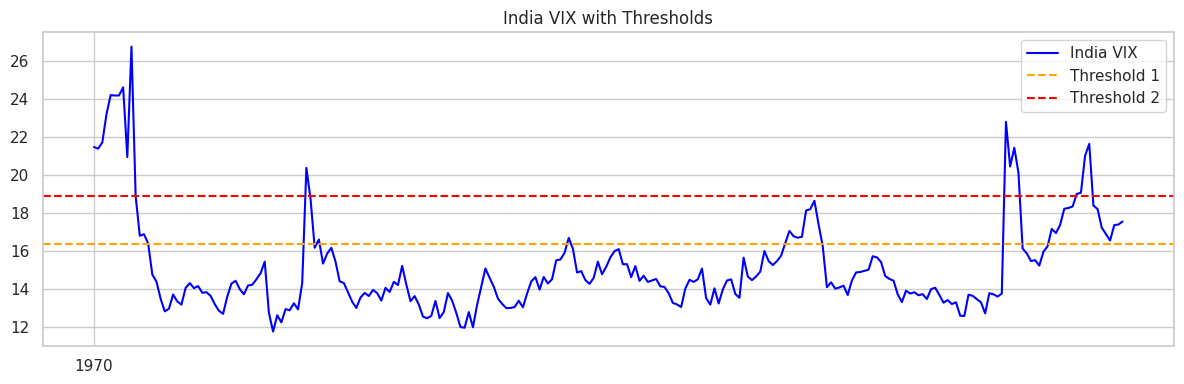

<ipython-input-42-8fb86787dbe5>:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  vf = vix.reindex(dates, method='ffill').fillna(method='bfill')



=== ADANIGREEN Dynamic Backtest ===
Net Return: 645996.83%
Max Drawdown: -14.65%
Sharpe Ratio: 1.93
VaR(95%): -17169705.73, CVaR(95%): -62610768.14


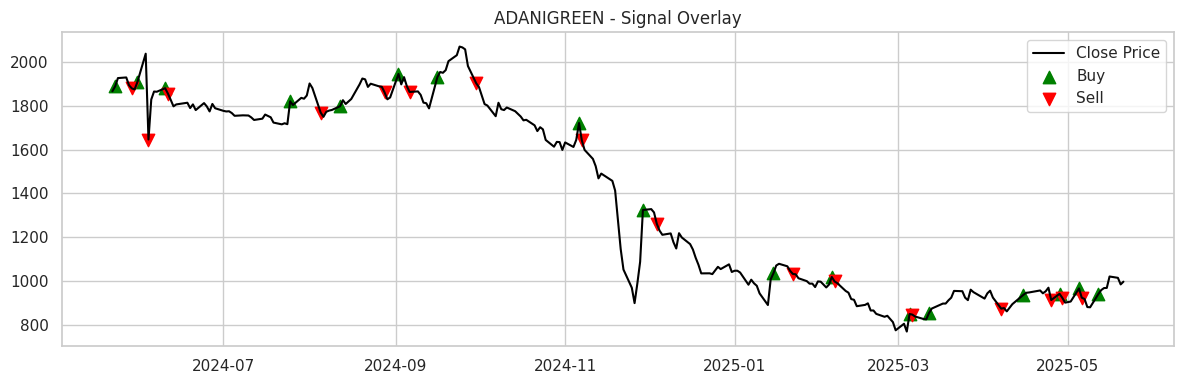

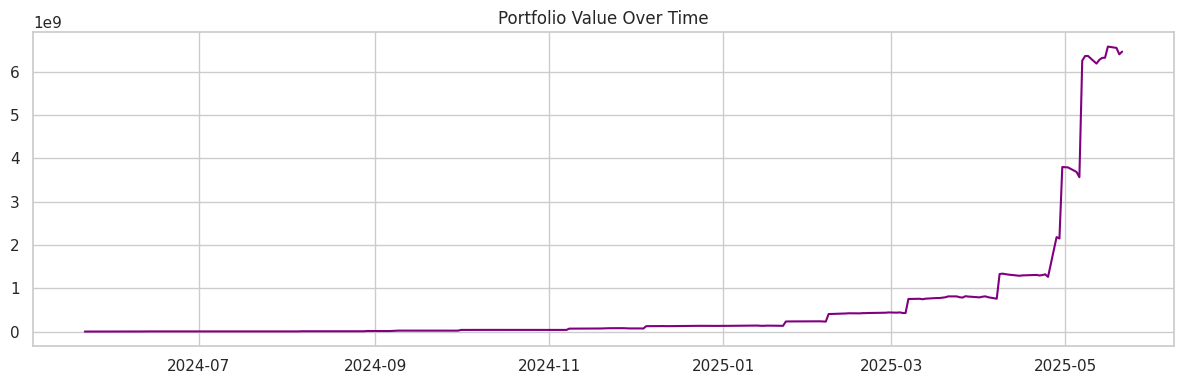

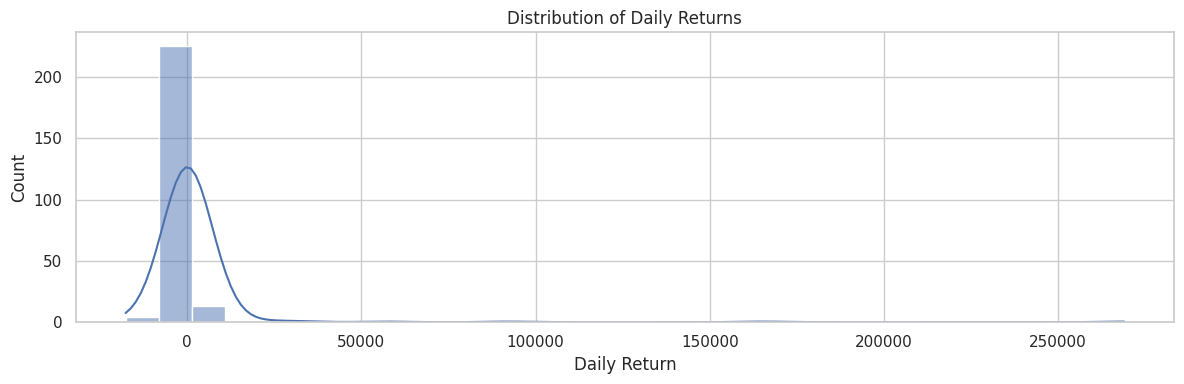


=== BEL Dynamic Backtest ===
Net Return: 177845.41%
Max Drawdown: -15.21%
Sharpe Ratio: 2.48
VaR(95%): -9068991.44, CVaR(95%): -15082215.84


<ipython-input-42-8fb86787dbe5>:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  vf = vix.reindex(dates, method='ffill').fillna(method='bfill')


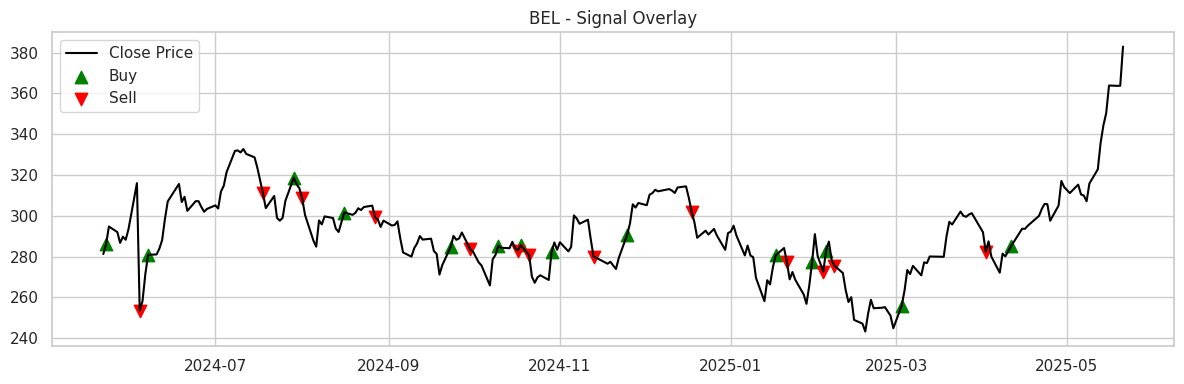

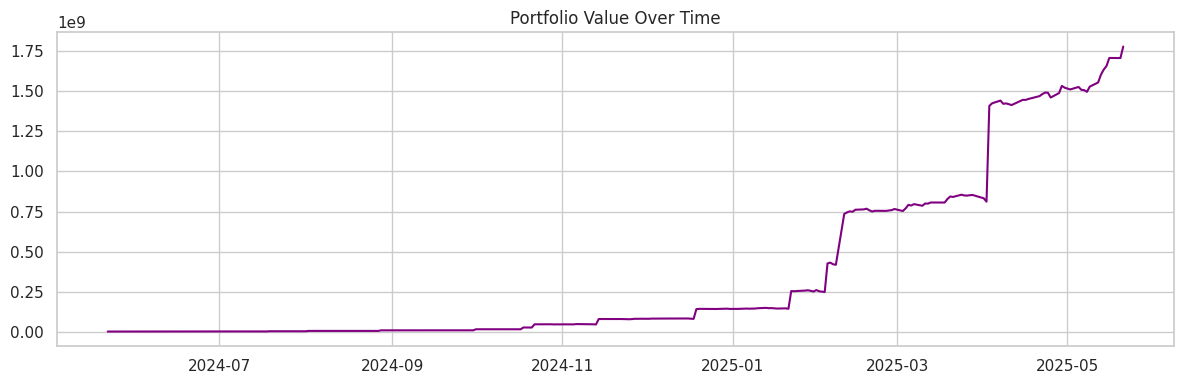

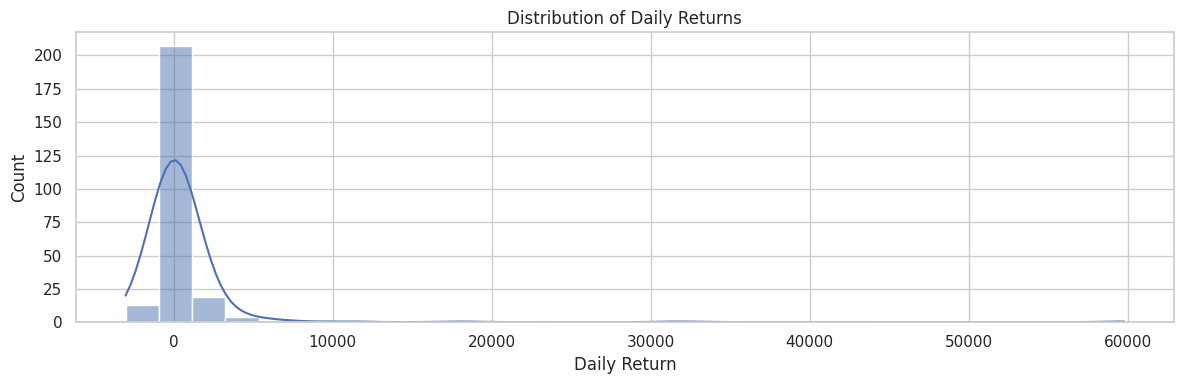

In [50]:
# Plot VIX thresholds once
plot_vix_with_thresholds(vix_df['Close'], threshold_1, threshold_2)

# Use EMA crossover signals from Part I
start, end = '2024-05-22', '2025-05-22'
for ticker, df in [('ADANIGREEN', adani), ('BEL', bel)]:
    df = df.copy()
    signals = ema_crossover_strategy(df)

    # Ensure VIX series index is datetime
    vix_series = vix_df['Close']
    vix_series.index = pd.to_datetime(vix_df.index)

    # Apply dynamic capital allocation
    capital_factors = capital_allocation(df.index, vix_series, threshold_1, threshold_2)

    # Run backtest
    trades_dyn, daily_dyn = backtest_dynamic(df, signals['signal'], 1e6, capital_factors)

    # Compute metrics
    net_return = (daily_dyn['Portfolio Value'].iloc[-1] / 1e6 - 1) * 100
    peak = daily_dyn['Portfolio Value'].cummax()
    max_dd = ((daily_dyn['Portfolio Value'] - peak)/peak).min() * 100
    sharpe = daily_dyn['Daily Return'].mean() / daily_dyn['Daily Return'].std() * np.sqrt(252)
    var95 = calculate_var(daily_dyn['Daily PnL'], 0.95)
    cvar95 = calculate_cvar(daily_dyn['Daily PnL'], 0.95)

    # Print metrics
    print(f"\n=== {ticker} Dynamic Backtest ===")
    print(f"Net Return: {net_return:.2f}%")
    print(f"Max Drawdown: {max_dd:.2f}%")
    print(f"Sharpe Ratio: {sharpe:.2f}")
    print(f"VaR(95%): {var95:.2f}, CVaR(95%): {cvar95:.2f}")

    # === VISUALS ===
    plot_signals(df, signals['signal'], title=f'{ticker} - Signal Overlay')
    plot_portfolio_value(daily_dyn)
    plot_return_distribution(daily_dyn)


    Signal Generation:
    Used an EMA crossover strategy to generate Buy (+1) and Sell (−1) signals on stock price data.

    Volatility Adjustment (VIX):
    Fetched historical India VIX data and computed two volatility thresholds:

        Threshold 1 = μ + 0.5σ

        Threshold 2 = μ + 1.5σ

    Capital Allocation Logic:
    Based on VIX level:

        VIX < T1 → 100% capital

        T1 ≤ VIX < T2 → 75% capital

        VIX ≥ T2 → 50% capital

    Backtesting Engine:
    Simulated trades using dynamic position sizing (capital allocation affected by VIX level), tracking portfolio value and daily returns.

    Risk Metrics Computed:

        Net Return

        Maximum Drawdown

        Sharpe Ratio

        VaR(95%) & CVaR(95%)

    Visualizations

    India VIX with thresholds

    Buy/Sell signal overlay on price chart

    Portfolio value over time

    Histogram of daily returns